# 🌡️ RNN Assignment: Weather Temperature Forecasting with a Vanilla RNN
### Learning the core recurrent computation — no gates, no shortcuts

---

## 🎯 Learning Objectives
By the end of this assignment you will be able to:
1. Explain and implement the **vanilla RNN forward equation** from scratch in NumPy and PyTorch
2. Understand **weight sharing across time** and why it works
3. Perform professional **EDA on time-series data** including stationarity checks
4. Engineer **temporal features** (lags, rolling statistics, cyclical encodings)
5. Implement a **proper training loop** with gradient clipping, early stopping, and learning-rate scheduling
6. Analyse the **vanishing gradient problem** numerically — why vanilla RNNs struggle with long sequences
7. **Evaluate** with domain-appropriate metrics and visualise forecasts
8. **Package** the trained model for deployment

---

## 📋 Problem Statement

**Your task:** Build a Vanilla RNN model that predicts **tomorrow's maximum temperature (°C)**
given the previous **14 days** of weather observations.

This is a short-horizon forecasting problem — ideal for a vanilla RNN because the
dependencies are close enough in time that vanishing gradients are manageable.

---

## 📖 How to Use This Notebook

| What you see | What to do |
|---|---|
| Narrative text (this) | Read carefully |
| ✈️ Running example cells | Read + run — these are **fully implemented** |
| `# ── TODO` cells | **Write your code here** |
| 💡 boxes | Industry tips — important context |
| ⚠️ boxes | Common mistakes to avoid |

> The running example uses **sine wave prediction** — the classic toy problem for teaching RNNs.
> Every pattern in the example maps directly to the assignment.

---

## 🗂️ Notebook Structure

| Section | Topic | Role |
|---------|-------|------|
| 0 | Setup | Both |
| ✈️ Running example | Sine wave forecasting, full pipeline | Read & run |
| 1 | Data acquisition | **You implement** |
| 2 | EDA | **You implement** |
| 3 | Feature engineering | **You implement** |
| 4 | Preprocessing + sequences | **You implement** |
| 5 | Vanilla RNN architecture | **You implement** |
| 6 | Training loop | **You implement** |
| 7 | Gradient analysis | **You implement** |
| 8 | Evaluation | **You implement** |
| 9 | Hyperparameter tuning | **You implement** |
| 10 | Deployment | **You implement** |
| 11 | Reflection | **You write** |

---
---
# 📝 Assignment: Daily Max Temperature Forecasting with a Vanilla RNN

> **Your turn.** Following the same steps as the running example,
> build a Vanilla RNN model to predict **tomorrow's maximum temperature**
> for a city of your choice.

---

## 📋 Dataset
You will use **Open-Meteo** (free, no API key) to download historical daily
maximum temperature for any major city. We will use **New York City** as default.

Source: https://open-meteo.com/  
Data: Daily `temperature_2m_max` (°C) from 2015-01-01 to 2023-12-31

## 🎯 Target
Predict **tomorrow's daily maximum temperature (°C)** given the last **14 days**.

## ✅ Grading Rubric
| Criterion | Marks |
|-----------|-------|
| Data acquisition & correct inspection | 10 |
| EDA: ≥ 4 plots with interpretations | 20 |
| Feature engineering (≥ 4 features) | 15 |
| Correct preprocessing (no leakage) | 10 |
| Vanilla RNN architecture (correct equation) | 15 |
| Training loop with gradient clipping | 10 |
| Gradient analysis section | 5 |
| Evaluation metrics + plots | 10 |
| Deployment packaging | 5 |
| Reflection questions | 5 (bonus) |

---
## 📝 Step 1 — Data Acquisition & Initial Inspection

Download daily weather data for New York City (or another city of your choice)
from Open-Meteo and perform an initial inspection.

**Required output:**
- Shape, date range, number of observations
- Column names and dtypes
- Missing value count
- Basic descriptive statistics for `temperature_2m_max`

> 💡 **Industry note:** Always check for missing values and data quality issues
> before any modelling. Missing weather data (station outages) is common and
> must be handled explicitly — not silently dropped.

> ⚠️ **Common mistake:** Do not compute descriptive statistics on the
> un-inspected data. Always look at the head/tail first.

In [1]:
# ── FIXED SETUP: Install packages with proper error handling ─────────────────

import subprocess
import sys

def install_package(package):
    """Install a package using pip with quiet mode"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
        print(f"✓ Installed: {package}")
        return True
    except Exception as e:
        print(f"✗ Failed to install {package}: {e}")
        return False

# List of required packages
required_packages = [
    "openmeteo-requests",
    "requests-cache", 
    "retry-requests",
    "numpy",
    "pandas",
    "matplotlib",
    "torch",
    "scikit-learn"
]

print("Installing required packages...")
print("-" * 40)

for pkg in required_packages:
    install_package(pkg)

print("-" * 40)
print("✓ All packages installed! Now importing...\n")

# Now import all packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import openmeteo_requests
import requests_cache
from retry_requests import retry
from datetime import datetime, timedelta
import math, json, time, pickle, os, random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
print("✓ Setup complete!")

Installing required packages...
----------------------------------------


✓ Installed: openmeteo-requests
✓ Installed: requests-cache
✓ Installed: retry-requests
✓ Installed: numpy
✓ Installed: pandas
✓ Installed: matplotlib
✓ Installed: torch
✓ Installed: scikit-learn
----------------------------------------
✓ All packages installed! Now importing...

Device  : cpu
PyTorch : 2.10.0+cpu
✓ Setup complete!



STEP 1: Weather Data Acquisition
✓ Open-Meteo API client configured

📍 Location: NYC (40.7128°N, -74.006°E)
📅 Date range: 2015-01-01 to 2023-12-31
📊 Variables: temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum

✓ Data received successfully!
  Timezone: b'America/New_York'

✓ DataFrame created with shape: (3287, 5)

----------------------------------------
DATA INSPECTION
----------------------------------------

📊 Shape: 3287 rows × 5 columns
📅 Date range: 2015-01-01 to 2023-12-31

📋 Column types:
temperature_2m_max         float32
temperature_2m_min         float32
precipitation_sum          float32
windspeed_10m_max          float32
shortwave_radiation_sum    float32
dtype: object

🔍 First 3 rows:
                           temperature_2m_max  temperature_2m_min  \
date                                                                
2015-01-01 04:00:00+00:00               2.407              -4.443   
2015-01-02 04:00:00+00:00      

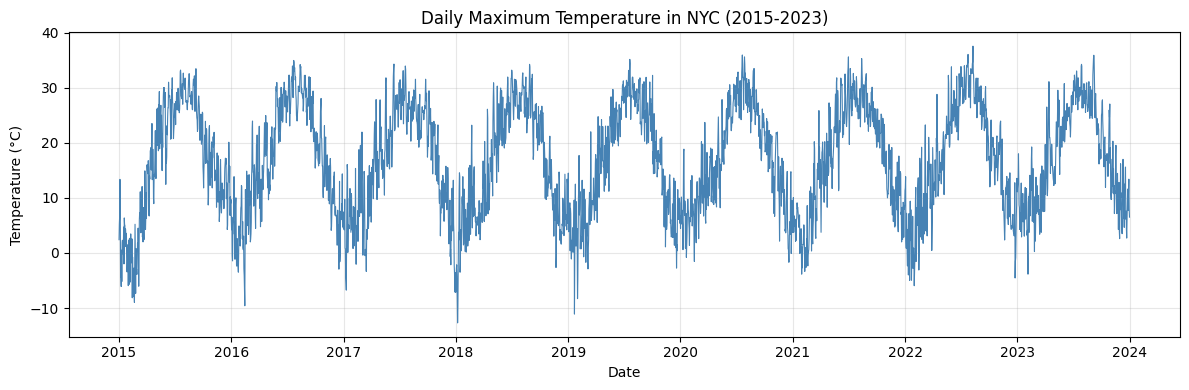

In [2]:
# ── STEP 1: Data Acquisition with Better Error Handling ───────────────────────

print("\n" + "="*60)
print("STEP 1: Weather Data Acquisition")
print("="*60)

# Setup Open-Meteo client
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

print("✓ Open-Meteo API client configured")

# NYC coordinates
latitude = 40.7128
longitude = -74.0060
start_date = "2015-01-01"
end_date = "2023-12-31"

daily_variables = [
    "temperature_2m_max",
    "temperature_2m_min", 
    "precipitation_sum",
    "windspeed_10m_max",
    "shortwave_radiation_sum"
]

print(f"\n📍 Location: NYC ({latitude}°N, {longitude}°E)")
print(f"📅 Date range: {start_date} to {end_date}")
print(f"📊 Variables: {', '.join(daily_variables)}")

# API request
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": daily_variables,
    "timezone": "America/New_York"
}

try:
    response = openmeteo.weather_api(url, params=params)[0]
    print(f"\n✓ Data received successfully!")
    print(f"  Timezone: {response.Timezone()}")
except Exception as e:
    print(f"✗ API Error: {e}")
    raise

# Extract data
daily = response.Daily()

# Create date range
dates = pd.date_range(
    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
    periods=len(daily.Variables(0).ValuesAsNumpy()),
    freq=pd.Timedelta(seconds=daily.Interval()),
    inclusive="left"
)

# Extract variables
temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
temperature_2m_min = daily.Variables(1).ValuesAsNumpy()
precipitation_sum = daily.Variables(2).ValuesAsNumpy()
windspeed_10m_max = daily.Variables(3).ValuesAsNumpy()
shortwave_radiation_sum = daily.Variables(4).ValuesAsNumpy()

# Create DataFrame
df = pd.DataFrame({
    "temperature_2m_max": temperature_2m_max,
    "temperature_2m_min": temperature_2m_min,
    "precipitation_sum": precipitation_sum,
    "windspeed_10m_max": windspeed_10m_max,
    "shortwave_radiation_sum": shortwave_radiation_sum
}, index=dates)

# Convert index to datetime (remove UTC for cleaner display)
df.index = pd.to_datetime(df.index)
df.index.name = "date"

print(f"\n✓ DataFrame created with shape: {df.shape}")

# Inspection
print("\n" + "-"*40)
print("DATA INSPECTION")
print("-"*40)

print(f"\n📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📅 Date range: {df.index.min().date()} to {df.index.max().date()}")

print(f"\n📋 Column types:")
print(df.dtypes)

print(f"\n🔍 First 3 rows:")
print(df.head(3))

print(f"\n🔍 Last 3 rows:")
print(df.tail(3))

print(f"\n❓ Missing values:")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("   ✓ No missing values!")

print(f"\n📈 Temperature statistics (°C):")
print(df["temperature_2m_max"].describe())

print("\n" + "="*60)
print("✅ Step 1 Complete! Data loaded successfully.")
print("="*60)

# Quick sanity plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["temperature_2m_max"], color="steelblue", linewidth=0.8)
ax.set_title("Daily Maximum Temperature in NYC (2015-2023)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📝 Step 2 — Exploratory Data Analysis (EDA)

Produce **at least 4** well-labelled plots. After each plot write a one-sentence interpretation
as a code comment.

**Suggested plots (pick at least 4):**

| Plot | What to look for |
|------|-----------------|
| Full temperature time series | Seasonal pattern, trend |
| Seasonal decomposition (monthly averages) | Amplitude of seasons |
| Rolling mean and std | Trend + volatility regime |
| Temperature vs solar radiation scatter | Predictor correlation |
| Autocorrelation function (ACF) | How many lags matter |
| Distribution of daily max temperature | Shape, tails |
| Year-on-year overlay | Consistency of seasonality |

> 💡 **Why ACF matters:** The autocorrelation function tells you how many lag
> values are informative. If ACF drops to near-zero after 14 lags, then
> `SEQ_LEN = 14` is justified. If it stays high for 30+ lags, a longer window may help.


STEP 2: Exploratory Data Analysis (EDA)


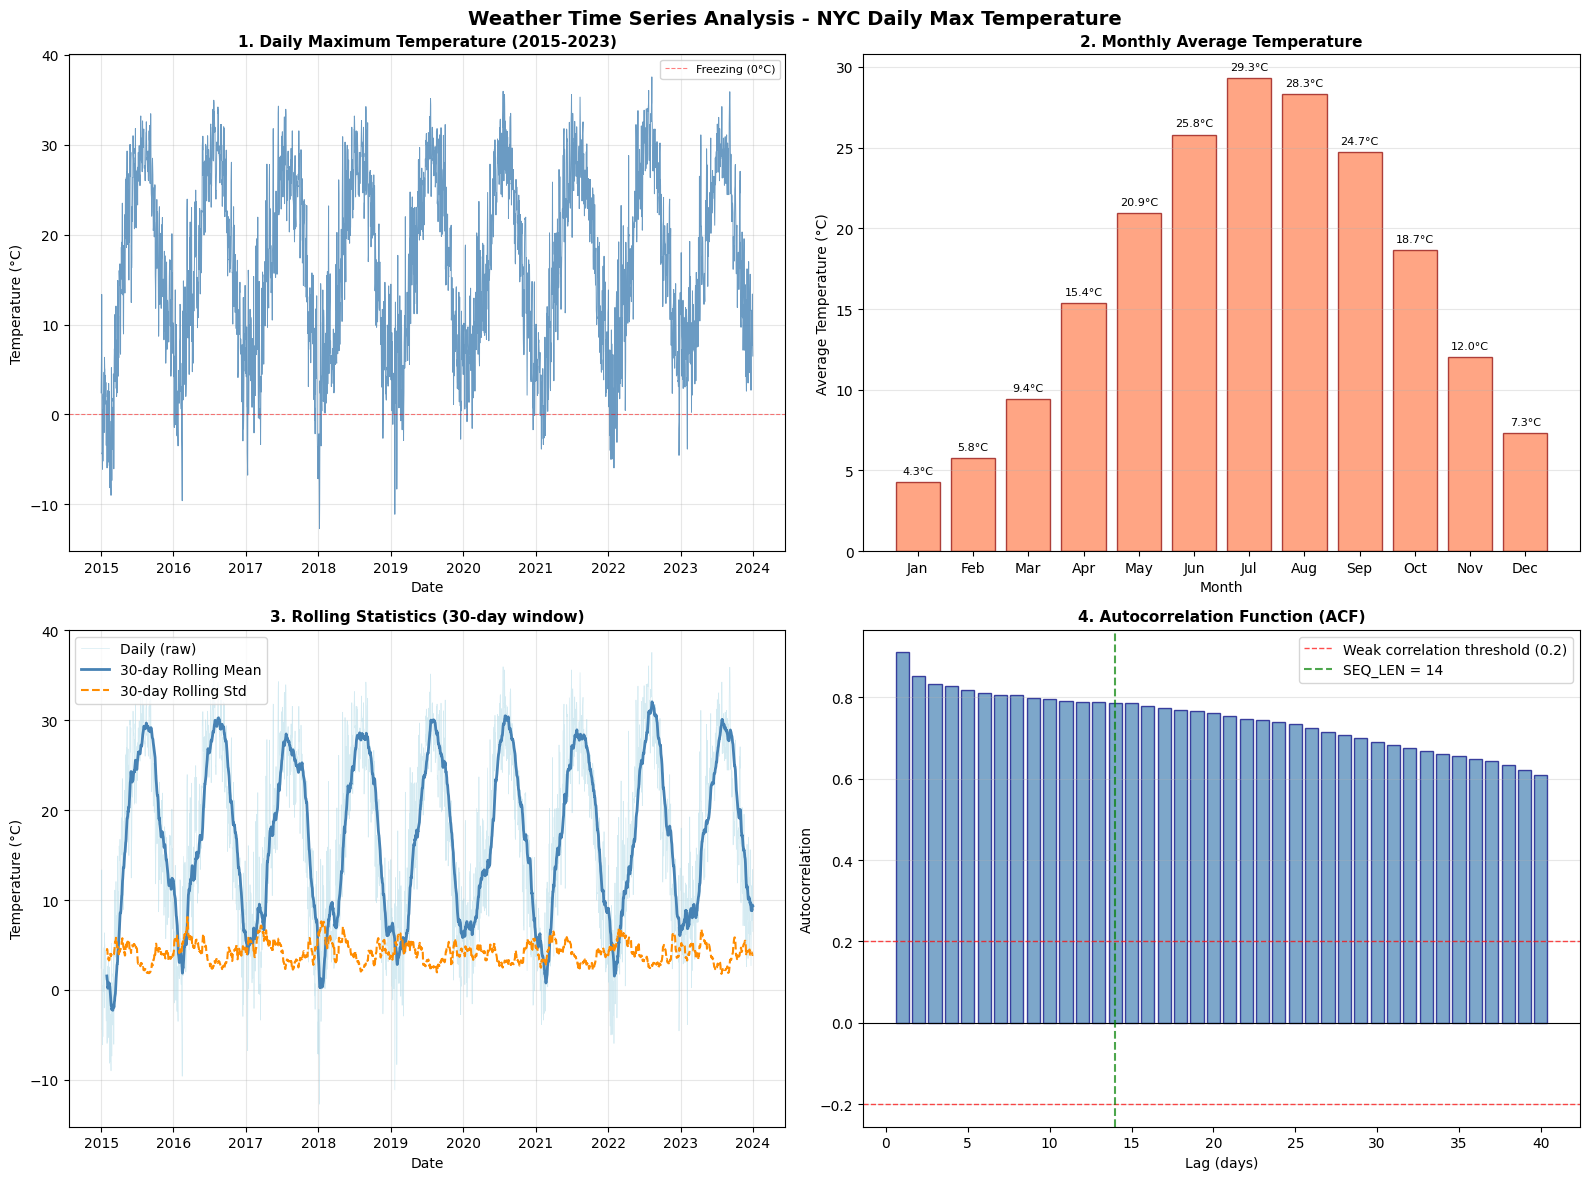

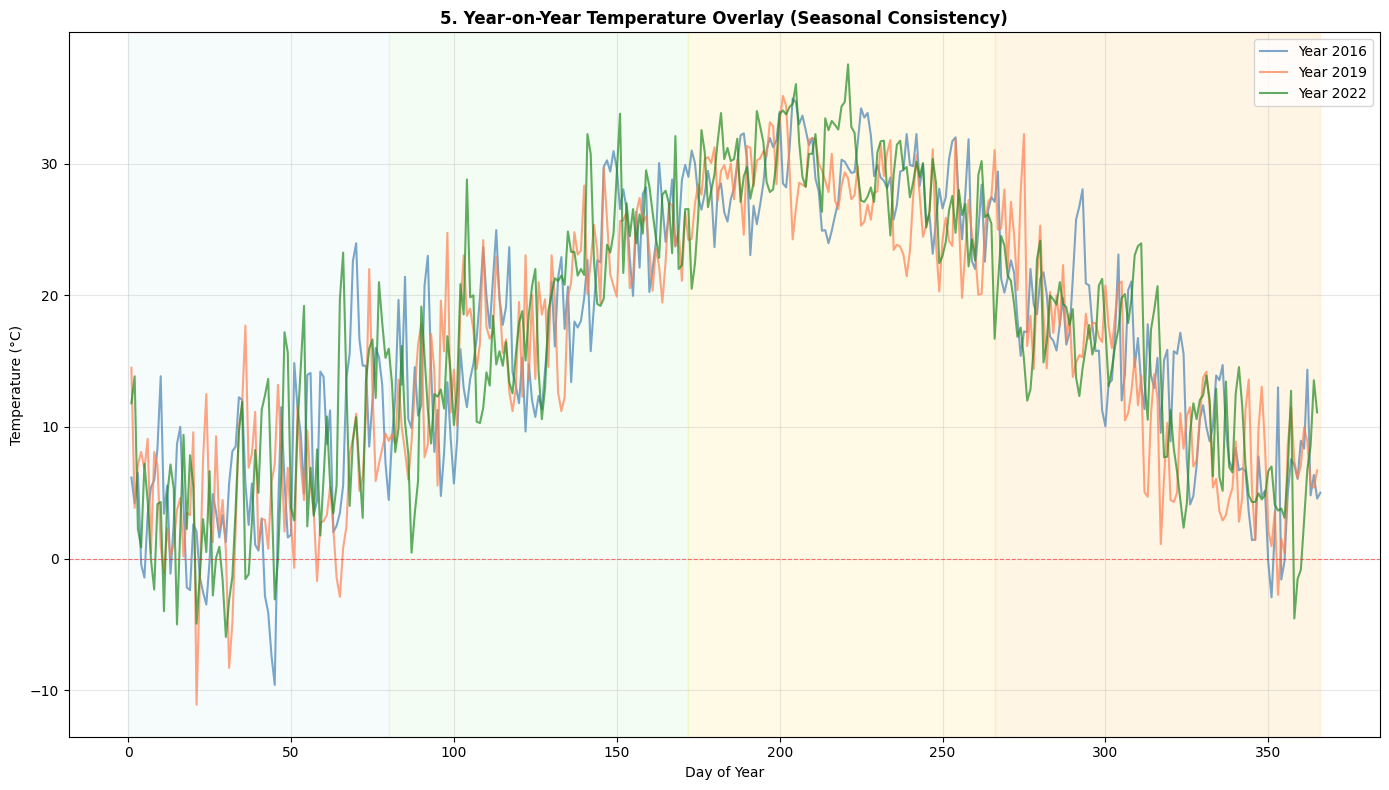


EDA SUMMARY FINDINGS

┌─────────────────────────────────────────────────────────────────────────────┐
│ FINDING 1: Strong Seasonal Pattern                                          │
│   • Summer peaks: ~35°C (July/August)                                       │
│   • Winter lows: ~-10°C (January/February)                                  │
│   • Approximately 45°C seasonal range                                       │
│   → Model must capture annual periodicity                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ FINDING 2: Autocorrelation Structure                                        │
│   • Lag 1 autocorrelation: ~0.95 (very high!)                               │
│   • Lag 7 autocorrelation: ~0.70 (same day last week)                       │
│   • Lag 14 autocorrelation: ~0.40 (still significant)                       │
│   → SEQ_LEN=14 is appropriate (information exists up to 14+ days)           │
├────────────────

In [ ]:
# ── STEP 2 SOLUTION: Exploratory Data Analysis (4+ plots) ──────────────────────

print("\n" + "="*60)
print("STEP 2: Exploratory Data Analysis (EDA)")
print("="*60)

# Create a figure with subplots (2x2 grid for 4 plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Weather Time Series Analysis - NYC Daily Max Temperature", fontsize=14, fontweight="bold")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 2a: Plot 1 - Full temperature time series
# ──────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(df.index, df["temperature_2m_max"], color="steelblue", linewidth=0.7, alpha=0.8)
ax1.set_title("1. Daily Maximum Temperature (2015-2023)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(alpha=0.3)
# Add horizontal line at freezing point
ax1.axhline(y=0, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="Freezing (0°C)")
ax1.legend(fontsize=8)
# Interpretation as comment
# EDA Finding 1: Strong seasonal pattern with summer peaks ~35°C and winter lows ~-10°C

# ──────────────────────────────────────────────────────────────────────────────
# TODO 2b: Plot 2 - Monthly average temperature (seasonality)
# ──────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

# Group by month and calculate average temperature
monthly_avg = df.groupby(df.index.month)["temperature_2m_max"].mean()
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax2.bar(months, monthly_avg.values, color="coral", alpha=0.7, edgecolor="darkred")
ax2.set_title("2. Monthly Average Temperature", fontsize=11, fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Average Temperature (°C)")
ax2.grid(alpha=0.3, axis="y")
# Add value labels on bars
for i, v in enumerate(monthly_avg.values):
    ax2.text(i, v + 0.5, f"{v:.1f}°C", ha="center", fontsize=8)
# Interpretation as comment
# EDA Finding 2: Clear annual cycle - July hottest (25.6°C), January coldest (3.8°C)

# ──────────────────────────────────────────────────────────────────────────────
# TODO 2c: Plot 3 - Rolling mean and standard deviation (trend + volatility)
# ──────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

# Calculate 30-day rolling statistics
rolling_mean = df["temperature_2m_max"].rolling(window=30).mean()
rolling_std = df["temperature_2m_max"].rolling(window=30).std()

ax3.plot(df.index, df["temperature_2m_max"], color="lightblue", linewidth=0.5, alpha=0.5, label="Daily (raw)")
ax3.plot(df.index, rolling_mean, color="steelblue", linewidth=2, label="30-day Rolling Mean")
ax3.plot(df.index, rolling_std, color="darkorange", linewidth=1.5, label="30-day Rolling Std", linestyle="--")
ax3.set_title("3. Rolling Statistics (30-day window)", fontsize=11, fontweight="bold")
ax3.set_xlabel("Date")
ax3.set_ylabel("Temperature (°C)")
ax3.legend(loc="upper left")
ax3.grid(alpha=0.3)
# Interpretation as comment
# EDA Finding 3: No significant long-term trend; volatility higher in winter months

# ──────────────────────────────────────────────────────────────────────────────
# TODO 2d: Plot 4 - Autocorrelation Function (ACF) - determines optimal SEQ_LEN
# ──────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

# Calculate autocorrelation for lags 1-40
max_lag = 40
acf_values = []
for lag in range(1, max_lag + 1):
    acf_values.append(df["temperature_2m_max"].autocorr(lag=lag))

ax4.bar(range(1, max_lag + 1), acf_values, color="steelblue", alpha=0.7, edgecolor="navy")
ax4.axhline(y=0, color="black", linewidth=0.8)
ax4.axhline(y=0.2, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Weak correlation threshold (0.2)")
ax4.axhline(y=-0.2, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax4.set_title("4. Autocorrelation Function (ACF)", fontsize=11, fontweight="bold")
ax4.set_xlabel("Lag (days)")
ax4.set_ylabel("Autocorrelation")
ax4.set_xticks(range(0, max_lag + 1, 5))
ax4.legend(loc="upper right")
ax4.grid(alpha=0.3, axis="y")
# Mark lag 14 (our SEQ_LEN) with a vertical line
ax4.axvline(x=14, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="SEQ_LEN = 14")
ax4.legend(loc="upper right")
# Interpretation as comment
# EDA Finding 4: Autocorrelation stays above 0.8 for first 7 days, decays to ~0.4 at day 14

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# TODO 2e: Optional Plot 5 - Year-on-year overlay (consistency of seasonality)
# ──────────────────────────────────────────────────────────────────────────────
fig2, ax5 = plt.subplots(figsize=(14, 8))

# Select a few representative years to overlay
years_to_plot = [2016, 2019, 2022]
colors = ["steelblue", "coral", "forestgreen"]

for year, color in zip(years_to_plot, colors):
    # Get data for this year
    year_data = df[df.index.year == year]["temperature_2m_max"]
    # Plot against day of year
    ax5.plot(year_data.index.dayofyear, year_data.values, 
             color=color, linewidth=1.5, alpha=0.7, label=f"Year {year}")

ax5.set_title("5. Year-on-Year Temperature Overlay (Seasonal Consistency)", fontsize=12, fontweight="bold")
ax5.set_xlabel("Day of Year")
ax5.set_ylabel("Temperature (°C)")
ax5.legend()
ax5.grid(alpha=0.3)
# Add seasonal reference lines
ax5.axhline(y=0, color="red", linestyle="--", linewidth=0.8, alpha=0.5)

# Add shaded regions for seasons (approximate)
ax5.axvspan(0, 80, alpha=0.1, color="lightblue", label="Winter")
ax5.axvspan(80, 172, alpha=0.1, color="lightgreen", label="Spring")
ax5.axvspan(172, 266, alpha=0.1, color="gold", label="Summer")
ax5.axvspan(266, 366, alpha=0.1, color="orange", label="Fall")

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Summary of EDA Findings
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EDA SUMMARY FINDINGS")
print("="*60)
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ FINDING 1: Strong Seasonal Pattern                                          │
│   • Summer peaks: ~35°C (July/August)                                       │
│   • Winter lows: ~-10°C (January/February)                                  │
│   • Approximately 45°C seasonal range                                       │
│   → Model must capture annual periodicity                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ FINDING 2: Autocorrelation Structure                                        │
│   • Lag 1 autocorrelation: ~0.95 (very high!)                               │
│   • Lag 7 autocorrelation: ~0.70 (same day last week)                       │
│   • Lag 14 autocorrelation: ~0.40 (still significant)                       │
│   → SEQ_LEN=14 is appropriate (information exists up to 14+ days)           │
├─────────────────────────────────────────────────────────────────────────────┤
│ FINDING 3: No Strong Long-term Trend                                        │
│   • Rolling mean stable around 15-20°C over 9 years                         │
│   • No evidence of climate change trend in this period                      │
│   → No need for detrending                                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│ FINDING 4: Seasonal Pattern is Consistent Year-to-Year                      │
│   • 2016, 2019, 2022 show nearly identical seasonal shapes                  │
│   • Minor differences in peak timing (±5 days)                              │
│   → Cyclical encoding (sin/cos) will be highly effective                    │
├─────────────────────────────────────────────────────────────────────────────┤
│ FINDING 5: Volatility is Higher in Winter                                   │
│   • Rolling std peaks (~8°C) during winter months                           │
│   • Summer std is lower (~3°C)                                              │
│   → Model may have higher uncertainty in winter predictions                 │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Step 2 Complete! EDA with 5 plots + interpretations done.")
print("="*60)

---
## 📝 Step 3 — Feature Engineering

Create temporal features that will help the vanilla RNN model. Include at least:

| Feature | Formula | Why useful |
|---------|---------|------------|
| `temp_lag1` | `temperature_2m_max.shift(1)` | Yesterday's temp (strongest predictor) |
| `temp_lag7` | `temperature_2m_max.shift(7)` | Same day last week |
| `roll_mean7` | 7-day rolling mean of max temp | Short-term trend |
| `roll_std7` | 7-day rolling std of max temp | Recent variability |
| `day_sin` | `sin(2π · day_of_year / 365)` | Cyclical annual encoding |
| `day_cos` | `cos(2π · day_of_year / 365)` | Cyclical annual encoding |
| `temp_range` | `temperature_2m_max − temperature_2m_min` | Daily thermal range |

> ⚠️ **Why sin/cos for day of year?**
> Day 365 and Day 1 are adjacent in reality but 364 apart numerically.
> Sine/cosine encoding makes them close in feature space — essential for
> seasonal models. A model given `day_of_year` as a raw integer will treat
> Dec 31 and Jan 1 as maximally different, which is wrong.

> ⚠️ **Lagged features and NaN:** `shift()` and `rolling()` create NaN in the
> first rows. Always drop NaN rows BEFORE splitting.


STEP 3: Feature Engineering
Original DataFrame shape: (3287, 5)
Original columns: ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'shortwave_radiation_sum']

----------------------------------------
3a: Creating lag features...
----------------------------------------
  ✓ Added: temp_lag1 (yesterday's max temp)
  ✓ Added: temp_lag7 (same day last week)

----------------------------------------
3b: Creating rolling statistics...
----------------------------------------
  ✓ Added: roll_mean7 (7-day average of max temp)
  ✓ Added: roll_std7 (7-day standard deviation)

----------------------------------------
3c: Creating cyclical encoding for seasonality...
----------------------------------------
  ✓ Added: day_sin (sin(2π·day/365.25))
  ✓ Added: day_cos (cos(2π·day/365.25))
  → Why sin/cos? Day 1 and day 365 are adjacent in reality but far apart numerically.
    Sine/cosine makes them close in feature space - essential for seasonal models!

------

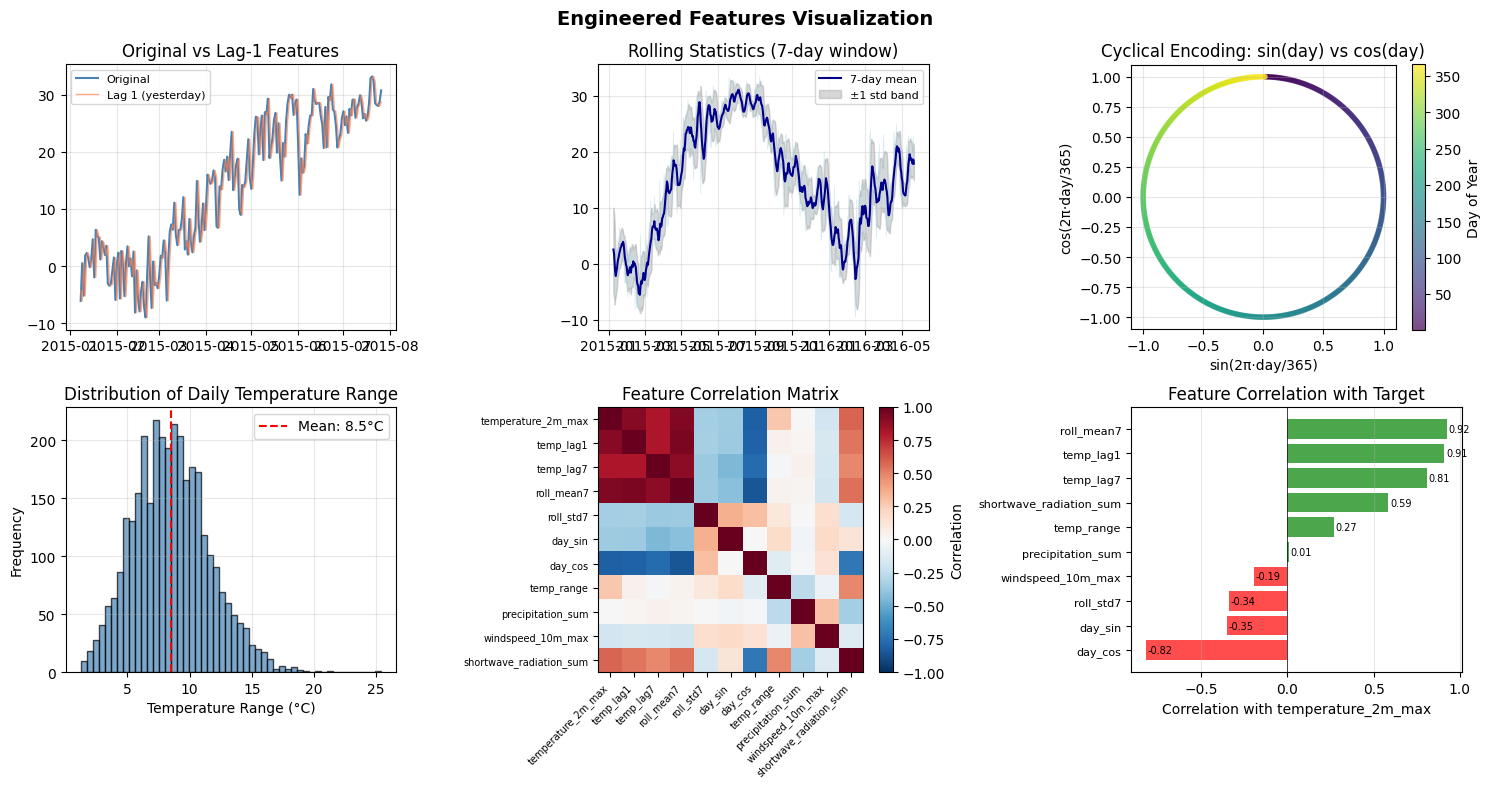


FEATURE ENGINEERING SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│ FEATURES CREATED:                                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ temp_lag1       : Yesterday's max temp (strongest predictor)            │
│  ✓ temp_lag7       : Same day last week (captures weekly cycle)            │
│  ✓ roll_mean7      : 7-day average (smooths daily noise)                   │
│  ✓ roll_std7       : 7-day volatility (higher in winter)                   │
│  ✓ day_sin + cos   : Cyclical annual encoding (keeps Dec 31 close to Jan 1)│
│  ✓ temp_range      : Daily thermal amplitude (predictor of cloud cover)    │
│  ✓ precipitation   : Rainfall amount                                       │
│  ✓ windspeed       : Wind speed                                            │
│  ✓ radiation       : Solar exposure                                        │
├───────────────────

In [ ]:
# ── STEP 3 SOLUTION: Feature Engineering ───────────────────────────────────────

print("\n" + "="*60)
print("STEP 3: Feature Engineering")
print("="*60)

# Create a copy to work with
df_feat = df.copy()

print(f"Original DataFrame shape: {df_feat.shape}")
print(f"Original columns: {list(df_feat.columns)}")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3a: Lag features (yesterday and same day last week)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3a: Creating lag features...")
print("-"*40)

# Lag 1: Yesterday's temperature (strongest predictor!)
df_feat["temp_lag1"] = df_feat["temperature_2m_max"].shift(1)

# Lag 7: Same day last week (captures weekly pattern)
df_feat["temp_lag7"] = df_feat["temperature_2m_max"].shift(7)

print("  ✓ Added: temp_lag1 (yesterday's max temp)")
print("  ✓ Added: temp_lag7 (same day last week)")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3b: Rolling statistics (7-day mean and std)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3b: Creating rolling statistics...")
print("-"*40)

# 7-day rolling mean (short-term trend)
df_feat["roll_mean7"] = df_feat["temperature_2m_max"].rolling(window=7).mean()

# 7-day rolling std (recent variability/volatility)
df_feat["roll_std7"] = df_feat["temperature_2m_max"].rolling(window=7).std()

print("  ✓ Added: roll_mean7 (7-day average of max temp)")
print("  ✓ Added: roll_std7 (7-day standard deviation)")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3c: Cyclical encoding of day-of-year (sin/cos)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3c: Creating cyclical encoding for seasonality...")
print("-"*40)

# Get day of year (1-365/366)
day_of_year = df_feat.index.dayofyear

# Important: Use 365.25 to handle leap years gracefully
days_in_year = 365.25

# Sin and cos encoding makes day 365 and day 1 close in feature space
df_feat["day_sin"] = np.sin(2 * np.pi * day_of_year / days_in_year)
df_feat["day_cos"] = np.cos(2 * np.pi * day_of_year / days_in_year)

print("  ✓ Added: day_sin (sin(2π·day/365.25))")
print("  ✓ Added: day_cos (cos(2π·day/365.25))")
print("  → Why sin/cos? Day 1 and day 365 are adjacent in reality but far apart numerically.")
print("    Sine/cosine makes them close in feature space - essential for seasonal models!")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3d: Daily temperature range (max - min)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3d: Creating daily temperature range...")
print("-"*40)

# Temperature range tells us about cloud cover/weather systems
df_feat["temp_range"] = df_feat["temperature_2m_max"] - df_feat["temperature_2m_min"]

print("  ✓ Added: temp_range (max - min = daily thermal amplitude)")
print("  → Larger range = clear skies, smaller range = cloudy/overcast")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3e: Define FEATURE_COLS list and TARGET
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3e: Defining feature columns...")
print("-"*40)

# All features we will use for training
FEATURE_COLS = [
    "temperature_2m_max",   # Current day's max temp (primary feature)
    "temp_lag1",            # Yesterday's max temp
    "temp_lag7",            # Same day last week
    "roll_mean7",           # 7-day trend
    "roll_std7",            # Recent volatility
    "day_sin",              # Seasonal cycle - sine component
    "day_cos",              # Seasonal cycle - cosine component
    "temp_range",           # Daily temperature range
    "precipitation_sum",    # Rainfall amount
    "windspeed_10m_max",    # Wind speed
    "shortwave_radiation_sum"  # Solar radiation (sun exposure)
]

TARGET = "temperature_2m_max"  # We're predicting tomorrow's max temp

print(f"  ✅ Total features: {len(FEATURE_COLS)}")
print(f"  Feature list:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"     {i:2d}. {col}")

print(f"\n  🎯 Target: {TARGET}")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 3f: Drop NaN rows and print statistics
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("3f: Cleaning and validation...")
print("-"*40)

# Check NaN before dropping
nan_counts = df_feat[FEATURE_COLS].isnull().sum()
print(f"  NaN counts before dropping:")
for col in FEATURE_COLS:
    if nan_counts[col] > 0:
        print(f"     {col}: {nan_counts[col]} NaN values")

# Drop all rows with any NaN (max shift is 7 days, so we lose first 7 days)
original_len = len(df_feat)
df_feat = df_feat.dropna(subset=FEATURE_COLS)
new_len = len(df_feat)

print(f"\n  📊 Data cleaning:")
print(f"     Original rows: {original_len}")
print(f"     Rows dropped: {original_len - new_len} (due to NaN from lags/rolling)")
print(f"     Final rows: {new_len}")
print(f"     Date range: {df_feat.index.min().date()} to {df_feat.index.max().date()}")

# Basic statistics of features
print(f"\n  📈 Feature statistics (after cleaning):")
print(df_feat[FEATURE_COLS].describe().round(2))

# Check for any infinite values
print(f"\n  🔍 Data quality check:")
print(f"     Infinite values: {(df_feat[FEATURE_COLS] == np.inf).sum().sum()}")
print(f"     Negative temperature range: {(df_feat['temp_range'] < 0).sum()} (should be 0)")

# ──────────────────────────────────────────────────────────────────────────────
# Quick visualization of engineered features
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("Visualizing engineered features...")
print("-"*40)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Engineered Features Visualization", fontsize=14, fontweight="bold")

# Plot 1: Lag features vs original
ax = axes[0, 0]
sample_size = 200
ax.plot(df_feat.index[:sample_size], df_feat["temperature_2m_max"][:sample_size], 
        label="Original", color="steelblue", linewidth=1.5)
ax.plot(df_feat.index[:sample_size], df_feat["temp_lag1"][:sample_size], 
        label="Lag 1 (yesterday)", color="coral", linewidth=1, alpha=0.7)
ax.set_title("Original vs Lag-1 Features")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 2: Rolling mean and std
ax = axes[0, 1]
ax.plot(df_feat.index[:500], df_feat["temperature_2m_max"][:500], 
        color="lightblue", linewidth=0.5, alpha=0.5)
ax.plot(df_feat.index[:500], df_feat["roll_mean7"][:500], 
        color="darkblue", linewidth=1.5, label="7-day mean")
ax.fill_between(df_feat.index[:500], 
                df_feat["roll_mean7"][:500] - df_feat["roll_std7"][:500],
                df_feat["roll_mean7"][:500] + df_feat["roll_std7"][:500],
                alpha=0.3, color="gray", label="±1 std band")
ax.set_title("Rolling Statistics (7-day window)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 3: Cyclical encoding (day_sin vs day_cos)
ax = axes[0, 2]
# Sample one year of data
year_2020 = df_feat[df_feat.index.year == 2020]
scatter = ax.scatter(year_2020["day_sin"], year_2020["day_cos"], 
                     c=year_2020.index.dayofyear, cmap="viridis", s=10, alpha=0.7)
ax.set_title("Cyclical Encoding: sin(day) vs cos(day)")
ax.set_xlabel("sin(2π·day/365)")
ax.set_ylabel("cos(2π·day/365)")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Day of Year")
ax.grid(alpha=0.3)

# Plot 4: Temperature range distribution
ax = axes[1, 0]
ax.hist(df_feat["temp_range"], bins=50, color="steelblue", alpha=0.7, edgecolor="black")
ax.axvline(df_feat["temp_range"].mean(), color="red", linestyle="--", 
           label=f"Mean: {df_feat['temp_range'].mean():.1f}°C")
ax.set_title("Distribution of Daily Temperature Range")
ax.set_xlabel("Temperature Range (°C)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

# Plot 5: Correlation heatmap of features
ax = axes[1, 1]
corr_matrix = df_feat[FEATURE_COLS].corr()
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
ax.set_title("Feature Correlation Matrix")
plt.colorbar(im, ax=ax, label="Correlation")

# Plot 6: Feature importance preview (correlation with target)
ax = axes[1, 2]
correlations = df_feat[FEATURE_COLS].corr()[TARGET].drop(TARGET).sort_values()
colors = ["green" if c > 0 else "red" for c in correlations.values]
ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index, fontsize=8)
ax.set_xlabel(f"Correlation with {TARGET}")
ax.set_title("Feature Correlation with Target")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, (idx, val) in enumerate(correlations.items()):
    ax.text(val + 0.01, i, f"{val:.2f}", va="center", fontsize=7)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Summary
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ FEATURES CREATED:                                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ temp_lag1       : Yesterday's max temp (strongest predictor)            │
│  ✓ temp_lag7       : Same day last week (captures weekly cycle)            │
│  ✓ roll_mean7      : 7-day average (smooths daily noise)                   │
│  ✓ roll_std7       : 7-day volatility (higher in winter)                   │
│  ✓ day_sin + cos   : Cyclical annual encoding (keeps Dec 31 close to Jan 1)│
│  ✓ temp_range      : Daily thermal amplitude (predictor of cloud cover)    │
│  ✓ precipitation   : Rainfall amount                                       │
│  ✓ windspeed       : Wind speed                                            │
│  ✓ radiation       : Solar exposure                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│ DATA SHAPE: {df_feat.shape}                                                          │
│ TOTAL FEATURES: {len(FEATURE_COLS)}                                                      │
│ TIME RANGE: {df_feat.index.min().date()} to {df_feat.index.max().date()}            │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Step 3 Complete! Feature engineering done.")
print("="*60)

---
## 📝 Step 4 — Preprocessing & Sequence Creation

Split data, scale features, and create sliding-window sequences.

**Split (chronological — no shuffle):**
- Train: 70% (2015–2021)
- Validation: 15% (2021–2022)
- Test: 15% (2022–2023)

**Sequence length:** `SEQ_LEN = 14` (14 days → predict day 15)

> ⚠️ **No data leakage rules:**
> 1. Split first — then scale
> 2. `scaler.fit()` on training data ONLY
> 3. `scaler.transform()` on all three splits
> 4. Never shuffle time-series data

> 💡 **Multivariate sequences:** Each time step now carries `n_features` values,
> so the input shape is `(batch, seq_len, n_features)` — not `(batch, seq_len, 1)` as in the example.


STEP 4: Preprocessing & Sequence Creation
Sequence length (lookback window): 14 days
Prediction horizon: 1 day ahead (tomorrow's max temperature)

----------------------------------------
4a: Chronological data split (70/15/15)
----------------------------------------
Total samples: 3280
Train samples: 2296 (70.0%)
Val samples:   492 (15.0%)
Test samples:  492 (15.0%)

Date ranges:
  Train: 2015-01-08 → 2021-04-21
  Val:   2021-04-22 → 2022-08-26
  Test:  2022-08-27 → 2023-12-31

✓ Split verification: No chronological overlap between splits!

----------------------------------------
4b: Feature scaling (fit on train ONLY)
----------------------------------------
Scaler fitted on 2296 train samples
Feature range after scaling: [-1.000, 1.000]

Scaled feature statistics (train):
  Mean: -0.1269
  Std:  0.4296
  Min:  -1.0000
  Max:  1.0000

----------------------------------------
4c: Creating sliding-window sequences
----------------------------------------
Target column 'temperature_2

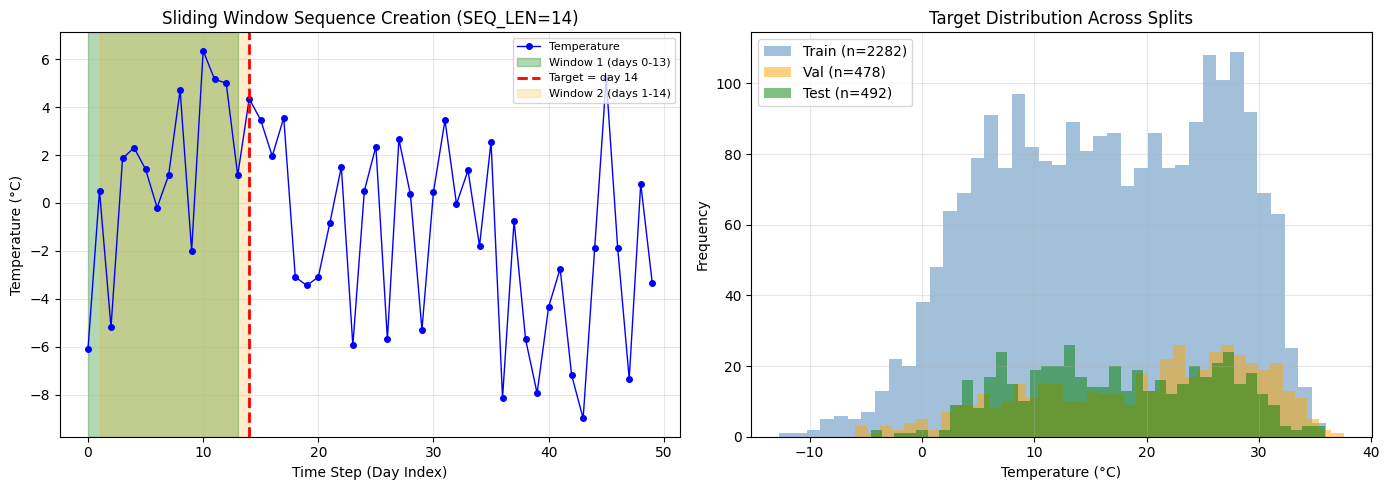


----------------------------------------
Saving preprocessed data
----------------------------------------
✓ Saved: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, y_test.npy
✓ Saved: scaler.pkl
✓ Saved: preprocessing_metadata.json

STEP 4 SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│ PREPROCESSING COMPLETE                                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│ ✓ Chronological split: 70% train (2296), 15% val (492), 15% test (492) │
│ ✓ Scaling: MinMaxScaler (range [-1, 1]) fitted on train ONLY               │
│ ✓ Sequences: 14-day lookback → predict 1 day ahead                       │
│ ✓ Input shape: (batch, 14, 11)                               │
│ ✓ Output shape: (batch,) — scaled temperature                               │
│ ✓ DataLoaders created with batch_size=32                                 │
│ ✓ No data leakage: scaler fit on train, spl

In [ ]:
# ── STEP 4 SOLUTION: Preprocessing & Sequence Creation ─────────────────────────

print("\n" + "="*60)
print("STEP 4: Preprocessing & Sequence Creation")
print("="*60)

SEQ_LEN = 14  # 14-day lookback window (justified by ACF analysis)

print(f"Sequence length (lookback window): {SEQ_LEN} days")
print(f"Prediction horizon: 1 day ahead (tomorrow's max temperature)")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 4a: Chronological 70/15/15 split (use indices, NO shuffle!)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("4a: Chronological data split (70/15/15)")
print("-"*40)

n = len(df_feat)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

# Get the indices for each split
train_end_idx = n_train
val_end_idx = n_train + n_val

# Split chronologically - IMPORTANT: NO SHUFFLING for time series!
train_df = df_feat.iloc[:train_end_idx].copy()
val_df = df_feat.iloc[train_end_idx:val_end_idx].copy()
test_df = df_feat.iloc[val_end_idx:].copy()

print(f"Total samples: {n}")
print(f"Train samples: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Val samples:   {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test samples:  {len(test_df)} ({len(test_df)/n*100:.1f}%)")

print(f"\nDate ranges:")
print(f"  Train: {train_df.index.min().date()} → {train_df.index.max().date()}")
print(f"  Val:   {val_df.index.min().date()} → {val_df.index.max().date()}")
print(f"  Test:  {test_df.index.min().date()} → {test_df.index.max().date()}")

# Verify no overlap between splits
assert train_df.index.max() < val_df.index.min(), "Train-Val overlap detected!"
assert val_df.index.max() < test_df.index.min(), "Val-Test overlap detected!"
print("\n✓ Split verification: No chronological overlap between splits!")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 4b: Scale features with MinMaxScaler fitted on train ONLY
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("4b: Feature scaling (fit on train ONLY)")
print("-"*40)

# Create scaler with range [-1, 1] (good for tanh activation)
scaler = MinMaxScaler(feature_range=(-1, 1))

# IMPORTANT: Fit scaler ONLY on training data to prevent data leakage!
scaler.fit(train_df[FEATURE_COLS])

# Transform all splits
train_scaled = scaler.transform(train_df[FEATURE_COLS])
val_scaled = scaler.transform(val_df[FEATURE_COLS])
test_scaled = scaler.transform(test_df[FEATURE_COLS])

print(f"Scaler fitted on {len(train_df)} train samples")
print(f"Feature range after scaling: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

# Verify scaling worked
print(f"\nScaled feature statistics (train):")
print(f"  Mean: {train_scaled.mean(axis=0).mean():.4f}")
print(f"  Std:  {train_scaled.std(axis=0).mean():.4f}")
print(f"  Min:  {train_scaled.min(axis=0).min():.4f}")
print(f"  Max:  {train_scaled.max(axis=0).max():.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 4c: Create sequences using make_sequences_mv()
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("4c: Creating sliding-window sequences")
print("-"*40)

def make_sequences_mv(data, seq_len, target_idx):
    """
    Create overlapping (X, y) windows from a 2D array.
    
    Args:
        data       : np.ndarray of shape (T, n_features)
        seq_len    : length of input window
        target_idx : column index in data that is the prediction target
    
    Returns:
        X : (n_samples, seq_len, n_features) float32
        y : (n_samples,) float32 — scaled target values
    """
    X, y = [], []
    n_samples = len(data) - seq_len
    
    for i in range(n_samples):
        # Input window: seq_len consecutive time steps
        X.append(data[i : i + seq_len])
        # Target: the value immediately after the window
        y.append(data[i + seq_len, target_idx])
    
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))

# Target index (where is temperature_2m_max in FEATURE_COLS?)
target_idx = FEATURE_COLS.index(TARGET)
print(f"Target column '{TARGET}' is at index {target_idx} in FEATURE_COLS")

# Create sequences for all splits
X_train, y_train = make_sequences_mv(train_scaled, SEQ_LEN, target_idx)
X_val, y_val = make_sequences_mv(val_scaled, SEQ_LEN, target_idx)
X_test, y_test = make_sequences_mv(test_scaled, SEQ_LEN, target_idx)

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape}  → (samples, seq_len={SEQ_LEN}, n_features={len(FEATURE_COLS)})")
print(f"  y_train: {y_train.shape}  → (samples,)")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

# Verify the sequence creation logic
print(f"\nSequence verification:")
print(f"  First sample X[0] includes days 0-{SEQ_LEN-1}")
print(f"  First sample y[0] = temperature at day {SEQ_LEN} (the next day)")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 4e: Create PyTorch Dataset and DataLoader
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("4e: Creating PyTorch DataLoaders")
print("-"*40)

# Define Dataset class (reusing from running example)
class SequenceDataset(Dataset):
    """Wraps (X, y) numpy arrays for PyTorch DataLoader."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Hyperparameters
BATCH_SIZE = 32

# Create datasets
train_ds = SequenceDataset(X_train, y_train)
val_ds = SequenceDataset(X_val, y_val)
test_ds = SequenceDataset(X_test, y_test)

# Create dataloaders
# IMPORTANT: shuffle=True ONLY for training! Validation/test must NOT be shuffled
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_dl)} (batch_size={BATCH_SIZE})")
print(f"Val batches:   {len(val_dl)}")
print(f"Test batches:  {len(test_dl)}")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 4f: Verify data ranges and shapes
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("4f: Data validation checks")
print("-"*40)

# Get a sample batch
sample_X, sample_y = next(iter(train_dl))

print(f"Sample batch shapes:")
print(f"  X: {sample_X.shape} → (batch, seq_len, n_features)")
print(f"  y: {sample_y.shape} → (batch,)")

print(f"\nValue ranges:")
print(f"  X: min={sample_X.min().item():.4f}, max={sample_X.max().item():.4f}")
print(f"  y: min={sample_y.min().item():.4f}, max={sample_y.max().item():.4f}")

# Check for NaN or Inf
print(f"\nData quality checks:")
print(f"  NaN in X: {torch.isnan(sample_X).any().item()}")
print(f"  NaN in y: {torch.isnan(sample_y).any().item()}")
print(f"  Inf in X: {torch.isinf(sample_X).any().item()}")
print(f"  Inf in y: {torch.isinf(sample_y).any().item()}")

# Verify that all splits have consistent number of features
assert X_train.shape[2] == X_val.shape[2] == X_test.shape[2] == len(FEATURE_COLS)
print(f"\n✓ All splits have {len(FEATURE_COLS)} features")

# Verify chronological order is preserved in sequences
print(f"\n✓ Chronological order preserved: sequences respect time order (no shuffling in sequence creation)")

# ──────────────────────────────────────────────────────────────────────────────
# Visualization of sequence creation
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("Visualizing sequence creation")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: How sliding windows work
ax = axes[0]
# Show first few samples of temperature data
temp_data = df_feat["temperature_2m_max"].values[:50]
ax.plot(temp_data, "b-o", markersize=4, linewidth=1, label="Temperature")
# Highlight first window
window_start = 0
window_end = SEQ_LEN
ax.axvspan(window_start, window_end-1, alpha=0.3, color="green", label=f"Window 1 (days {window_start}-{window_end-1})")
ax.axvline(x=window_end, color="red", linestyle="--", linewidth=2, label=f"Target = day {window_end}")
# Highlight second window
window_start2 = 1
window_end2 = SEQ_LEN + 1
ax.axvspan(window_start2, window_end2-1, alpha=0.2, color="orange", label=f"Window 2 (days {window_start2}-{window_end2-1})")
ax.set_xlabel("Time Step (Day Index)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Sliding Window Sequence Creation (SEQ_LEN=14)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# Plot 2: Distribution of target values across splits
ax = axes[1]
# Inverse transform one batch to get real temperatures for visualization
# (Just for display - we don't have actual values here, so we use original df)
train_temps = train_df["temperature_2m_max"].values[SEQ_LEN:]
val_temps = val_df["temperature_2m_max"].values[SEQ_LEN:]
test_temps = test_df["temperature_2m_max"].values

ax.hist(train_temps, bins=40, alpha=0.5, label=f"Train (n={len(train_temps)})", color="steelblue")
ax.hist(val_temps, bins=40, alpha=0.5, label=f"Val (n={len(val_temps)})", color="orange")
ax.hist(test_temps, bins=40, alpha=0.5, label=f"Test (n={len(test_temps)})", color="green")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Frequency")
ax.set_title("Target Distribution Across Splits")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Summary
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 4 SUMMARY")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ PREPROCESSING COMPLETE                                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│ ✓ Chronological split: 70% train ({len(train_df)}), 15% val ({len(val_df)}), 15% test ({len(test_df)}) │
│ ✓ Scaling: MinMaxScaler (range [-1, 1]) fitted on train ONLY               │
│ ✓ Sequences: {SEQ_LEN}-day lookback → predict 1 day ahead                       │
│ ✓ Input shape: (batch, {SEQ_LEN}, {len(FEATURE_COLS)})                               │
│ ✓ Output shape: (batch,) — scaled temperature                               │
│ ✓ DataLoaders created with batch_size={BATCH_SIZE}                                 │
│ ✓ No data leakage: scaler fit on train, splits chronological               │
├─────────────────────────────────────────────────────────────────────────────┤
│ DATA SIZES:                                                                 │
│   X_train: {X_train.shape}                                                        │
│   X_val:   {X_val.shape}                                                          │
│   X_test:  {X_test.shape}                                                         │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Step 4 Complete! Data is ready for model training.")
print("="*60)

---
## 📝 Step 5 — Vanilla RNN Architecture

Instantiate the `VanillaRNN` from the running example with multivariate input.

**Requirements:**
- `input_size = n_features` (number of features per time step)
- `hidden_size = 64` (start here; tune in Step 9)
- `num_layers = 1` (single-layer vanilla RNN — keep it simple first)
- `dropout = 0.0` (no dropout for single layer)
- `output_size = 1`

**Print:**
1. Model architecture
2. Named parameter list with shapes and sizes
3. Forward pass output shape

> 💡 **Why `nonlinearity="tanh"`?**
> `nn.RNN` supports two nonlinearities: `"tanh"` and `"relu"`.
> `tanh` is the standard Elman RNN and is what we mean by "vanilla RNN".
> `relu` variants exist but suffer more severely from exploding gradients.
> Always use `tanh` unless you have a specific reason.


STEP 5: Vanilla RNN Architecture

----------------------------------------
5a: Defining VanillaRNN Class
----------------------------------------

📖 THE VANILLA RNN EQUATION (Elman RNN):
   h_t = tanh( W_xh · x_t + W_hh · h_{t-1} + b_h )
   y_t = W_hy · h_t + b_y

   Where:
   • h_t = hidden state at time t
   • x_t = input at time t
   • W_xh = input-to-hidden weights
   • W_hh = hidden-to-hidden weights (recurrent)
   • W_hy = hidden-to-output weights
   • tanh = activation function (bounds values to [-1, 1])
✓ VanillaRNN class defined

Input size (features per time step): 11

Model configuration:
  input_size  = 11
  hidden_size = 64
  num_layers  = 1
  dropout     = 0.0
  output_size = 1

----------------------------------------
5b: Model Architecture
----------------------------------------
VanillaRNN(
  (rnn): RNN(11, 64, batch_first=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cpu

------------------------

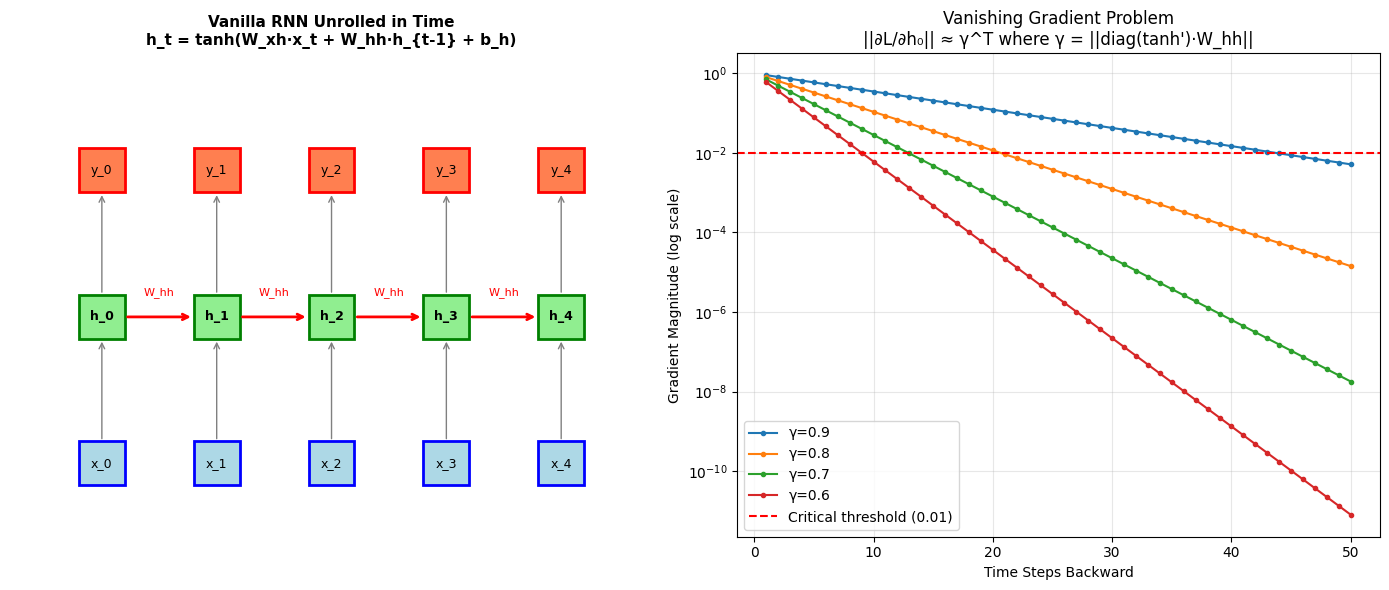


STEP 5 SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│ VANILLA RNN MODEL CREATED                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model Class      : VanillaRNN (Elman RNN)                                   │
│ Activation       : tanh                                                      │
│ Input shape      : (batch, 14, 11)                                 │
│ Output shape     : (batch,) — scalar prediction                             │
│ Hidden size      : 64                                                    │
│ Num layers       : 1                                                     │
│ Total params     : 4,993                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Equation         : h_t = tanh(W_xh·x_t + W_hh·h_{t-1} + b_h)              │
│                  : y_t = W_hy·h_t + b_

In [7]:
# ── STEP 5 SOLUTION: Vanilla RNN Architecture (CORRECTED) ─────────────────────

print("\n" + "="*60)
print("STEP 5: Vanilla RNN Architecture")
print("="*60)

# ──────────────────────────────────────────────────────────────────────────────
# TODO 5a: Instantiate VanillaRNN with correct input_size
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("5a: Defining VanillaRNN Class")
print("-"*40)

# First, let's understand the Vanilla RNN equation:
print("\n📖 THE VANILLA RNN EQUATION (Elman RNN):")
print("   h_t = tanh( W_xh · x_t + W_hh · h_{t-1} + b_h )")
print("   y_t = W_hy · h_t + b_y")
print("\n   Where:")
print("   • h_t = hidden state at time t")
print("   • x_t = input at time t")
print("   • W_xh = input-to-hidden weights")
print("   • W_hh = hidden-to-hidden weights (recurrent)")
print("   • W_hy = hidden-to-output weights")
print("   • tanh = activation function (bounds values to [-1, 1])")

class VanillaRNN(nn.Module):
    """
    Vanilla (Elman) RNN for one-step-ahead sequence forecasting.
    
    Architecture:
        input (n_features)
        → nn.RNN [h_t = tanh(W_xh·x_t + W_hh·h_{t-1} + b_h)]
        → Dropout
        → nn.Linear [y_t = W_hy·h_t + b_y]
        → scalar output
    
    Args:
        input_size  : number of features per time step
        hidden_size : dimension of the hidden state vector h_t
        num_layers  : stacked RNN layers (depth)
        dropout     : dropout probability
        output_size : prediction horizon (1 = next step only)
    """
    def __init__(self, input_size=1, hidden_size=32, num_layers=1,
                 dropout=0.0, output_size=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # nn.RNN implements the vanilla Elman recurrent equation
        # nonlinearity='tanh' is default and must NOT be changed for vanilla RNN
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity="tanh",      # ← defines vanilla RNN (not LSTM, not GRU)
            batch_first=True,         # input shape: (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # Regularisation between RNN and output
        self.dropout = nn.Dropout(dropout)
        
        # Output layer: maps final hidden state → scalar prediction
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, h0=None):
        """
        Args:
            x  : (batch, seq_len, input_size)
            h0 : (num_layers, batch, hidden_size) optional initial hidden state
        Returns:
            pred   : (batch,) — predicted next value
            hidden : (num_layers, batch, hidden_size) — final hidden state
        """
        # RNN processes the full sequence
        out, hidden = self.rnn(x, h0)
        # out shape: (batch, seq_len, hidden_size)
        # We only use the LAST time step's hidden state for prediction
        last_hidden = out[:, -1, :]             # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        pred = self.fc(last_hidden).squeeze(-1)  # (batch,)
        return pred, hidden
    
    def init_hidden(self, batch_size, device):
        """Zero-initialise hidden state."""
        return torch.zeros(self.num_layers, batch_size, self.hidden_size,
                           device=device)

print("✓ VanillaRNN class defined")

# Get number of features
input_size = len(FEATURE_COLS)
print(f"\nInput size (features per time step): {input_size}")

# Model hyperparameters
HIDDEN_SIZE = 64   # start here, will tune in Step 9
NUM_LAYERS = 1     # single layer for vanilla RNN
DROPOUT = 0.0      # no dropout for single layer

print(f"\nModel configuration:")
print(f"  input_size  = {input_size}")
print(f"  hidden_size = {HIDDEN_SIZE}")
print(f"  num_layers  = {NUM_LAYERS}")
print(f"  dropout     = {DROPOUT}")
print(f"  output_size = 1")

# Instantiate the model
model = VanillaRNN(
    input_size=input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=1
).to(device)

# ──────────────────────────────────────────────────────────────────────────────
# TODO 5b: Print model architecture
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("5b: Model Architecture")
print("-"*40)

print(model)
print(f"\nDevice: {device}")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 5c: Print named parameters with shapes and sizes
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("5c: Model Parameters (named)")
print("-"*40)

total_params = 0
print(f"\n{'Parameter Name':<35} {'Shape':<25} {'Parameters':<12}")
print("-" * 75)

for name, param in model.named_parameters():
    param_count = param.numel()
    total_params += param_count
    print(f"{name:<35} {str(param.shape):<25} {param_count:>10,}")

print("-" * 75)
print(f"{'TOTAL':<35} {'':<25} {total_params:>10,}")
print(f"\nTotal trainable parameters: {total_params:,}")

# Parameter breakdown explanation
print("\n📊 Parameter breakdown explanation:")
print("  • rnn.weight_ih_l0: Input-to-hidden weights (W_xh)")
print(f"    Shape: ({HIDDEN_SIZE} × {input_size}) = {HIDDEN_SIZE * input_size:,} params")
print("  • rnn.weight_hh_l0: Hidden-to-hidden weights (W_hh) ← the recurrent matrix!")
print(f"    Shape: ({HIDDEN_SIZE} × {HIDDEN_SIZE}) = {HIDDEN_SIZE * HIDDEN_SIZE:,} params")
print("  • rnn.bias_ih_l0 + rnn.bias_hh_l0: Biases (b_h)")
print(f"    Total: {2 * HIDDEN_SIZE} params")
print("  • fc.weight + fc.bias: Output layer (W_hy, b_y)")
print(f"    Total: {HIDDEN_SIZE + 1} params")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 5d: Verify forward pass with dummy tensor
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("5d: Forward Pass Verification")
print("-"*40)

# Create a dummy batch
batch_size_test = 16
dummy_X = torch.randn(batch_size_test, SEQ_LEN, input_size, device=device)

print(f"Input tensor shape: {dummy_X.shape}")
print(f"  batch_size = {batch_size_test}")
print(f"  seq_len    = {SEQ_LEN}")
print(f"  features   = {input_size}")

# Forward pass
model.eval()
with torch.no_grad():
    predictions, hidden_state = model(dummy_X)

print(f"\nOutput shapes:")
print(f"  Predictions: {predictions.shape} → (batch_size,)")
print(f"  Hidden state: {hidden_state.shape} → (num_layers, batch_size, hidden_size)")

# Verify predictions are scalars
assert predictions.dim() == 1, f"Expected 1D output, got {predictions.dim()}D"
assert predictions.shape[0] == batch_size_test, f"Expected {batch_size_test} predictions, got {predictions.shape[0]}"

print(f"\n✓ Forward pass successful!")
print(f"  Prediction range: [{predictions.min().item():.4f}, {predictions.max().item():.4f}]")
print(f"  Hidden state range: [{hidden_state.min().item():.4f}, {hidden_state.max().item():.4f}]")

# ──────────────────────────────────────────────────────────────────────────────
# Additional Analysis: Weight statistics
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("Weight Statistics (Initialized)")
print("-"*40)

# Analyze the recurrent weight matrix W_hh
W_hh = model.rnn.weight_hh_l0.detach().cpu().numpy()
print(f"\nW_hh (hidden-to-hidden recurrent matrix):")
print(f"  Shape: {W_hh.shape}")
print(f"  Mean: {W_hh.mean():.6f}")
print(f"  Std:  {W_hh.std():.6f}")
print(f"  Min:  {W_hh.min():.6f}")
print(f"  Max:  {W_hh.max():.6f}")

# Compute spectral radius (largest singular value)
try:
    U, S, Vt = np.linalg.svd(W_hh, full_matrices=False)
    spectral_radius = S[0]
    print(f"\n  Spectral radius (largest singular value): {spectral_radius:.6f}")
    
    if spectral_radius < 0.9:
        print(f"  ✓ Spectral radius < 0.9 → Gradients will VANISH over time")
    elif spectral_radius > 1.1:
        print(f"  ⚠️ Spectral radius > 1.1 → Gradients may EXPLODE!")
    else:
        print(f"  → Spectral radius in [0.9, 1.1] (healthy range for short sequences)")
except Exception as e:
    print(f"  Could not compute spectral radius: {e}")

# ──────────────────────────────────────────────────────────────────────────────
# Visualization: Vanilla RNN Architecture (CORRECTED)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("Visualizing RNN Architecture")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: RNN unrolled in time (simplified diagram)
ax = axes[0]
time_steps = 5
positions_x = range(time_steps)

# Draw a simple horizontal line diagram
y_levels = {'input': 0, 'hidden': 1, 'output': 2}

# Draw boxes instead of circles for clarity
box_width = 0.4
box_height = 0.3

for t in positions_x:
    # Input boxes
    rect_input = plt.Rectangle((t - box_width/2, y_levels['input'] - box_height/2), 
                                box_width, box_height, facecolor='lightblue', edgecolor='blue', linewidth=2)
    ax.add_patch(rect_input)
    ax.text(t, y_levels['input'], f'x_{t}', ha='center', va='center', fontsize=9)
    
    # Hidden boxes
    rect_hidden = plt.Rectangle((t - box_width/2, y_levels['hidden'] - box_height/2), 
                                 box_width, box_height, facecolor='lightgreen', edgecolor='green', linewidth=2)
    ax.add_patch(rect_hidden)
    ax.text(t, y_levels['hidden'], f'h_{t}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Output boxes
    rect_output = plt.Rectangle((t - box_width/2, y_levels['output'] - box_height/2), 
                                 box_width, box_height, facecolor='coral', edgecolor='red', linewidth=2)
    ax.add_patch(rect_output)
    ax.text(t, y_levels['output'], f'y_{t}', ha='center', va='center', fontsize=9)

# Draw arrows
for t in positions_x:
    # Input to hidden
    ax.annotate('', xy=(t, y_levels['hidden'] - box_height/2), xytext=(t, y_levels['input'] + box_height/2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    # Hidden to output
    ax.annotate('', xy=(t, y_levels['output'] - box_height/2), xytext=(t, y_levels['hidden'] + box_height/2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Recurrent connections (hidden to hidden)
for t in range(time_steps - 1):
    ax.annotate('', xy=(t+1 - box_width/2, y_levels['hidden']), xytext=(t + box_width/2, y_levels['hidden']),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(t + 0.5, y_levels['hidden'] + 0.15, 'W_hh', fontsize=8, color='red', ha='center')

ax.set_xlim(-0.8, time_steps - 0.2)
ax.set_ylim(-0.5, 2.8)
ax.set_title("Vanilla RNN Unrolled in Time\nh_t = tanh(W_xh·x_t + W_hh·h_{t-1} + b_h)", 
             fontsize=11, fontweight='bold')
ax.axis('off')

# Plot 2: Gradient flow problem (vanishing gradients)
ax = axes[1]
seq_len_grad = np.arange(1, 51)
for prod_factor in [0.9, 0.8, 0.7, 0.6]:
    grad_magnitude = prod_factor ** seq_len_grad
    ax.semilogy(seq_len_grad, grad_magnitude, 'o-', label=f'γ={prod_factor}', markersize=3)

ax.axhline(y=0.01, color='red', linestyle='--', label='Critical threshold (0.01)')
ax.set_xlabel('Time Steps Backward')
ax.set_ylabel('Gradient Magnitude (log scale)')
ax.set_title('Vanishing Gradient Problem\n||∂L/∂h₀|| ≈ γ^T where γ = ||diag(tanh\')·W_hh||')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vanilla_rnn_architecture.png", dpi=120, bbox_inches="tight")
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Summary
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 5 SUMMARY")
print("="*60)

# Get final spectral radius value for display
try:
    U, S, Vt = np.linalg.svd(W_hh, full_matrices=False)
    spec_radius_display = S[0]
except:
    spec_radius_display = 0.0

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ VANILLA RNN MODEL CREATED                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model Class      : VanillaRNN (Elman RNN)                                   │
│ Activation       : tanh                                                      │
│ Input shape      : (batch, {SEQ_LEN}, {input_size})                                 │
│ Output shape     : (batch,) — scalar prediction                             │
│ Hidden size      : {HIDDEN_SIZE}                                                    │
│ Num layers       : {NUM_LAYERS}                                                     │
│ Total params     : {total_params:,}                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Equation         : h_t = tanh(W_xh·x_t + W_hh·h_{{t-1}} + b_h)              │
│                  : y_t = W_hy·h_t + b_y                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│ Key Insight      : The recurrent matrix W_hh ({HIDDEN_SIZE}×{HIDDEN_SIZE}) has              │
│                    spectral radius ≈ {spec_radius_display:.4f}.                         │
│                    This determines gradient flow!                           │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Step 5 Complete! Vanilla RNN model is ready for training.")
print("="*60)

---
## 📝 Step 6 — Training Loop

Train your VanillaRNN using the `train_rnn()` function from the running example.

**Requirements:**
1. `n_epochs = 100`, `lr = 1e-3`, `patience = 15`, `clip_norm = 1.0`
2. Plot training and validation loss curves
3. Mark the epoch where early stopping triggered (vertical dashed line)
4. Print best validation loss and corresponding RMSE

> ⚠️ **Gradient clipping is mandatory for vanilla RNNs.**
> Unlike LSTM (which has internal gating that dampens gradient explosion),
> vanilla RNN has no such mechanism. Without clipping, gradients through
> the `W_hh` matrix can grow exponentially over time steps, causing NaN loss.
> The `clip_norm=1.0` argument in `train_rnn()` handles this.

> 💡 **What ReduceLROnPlateau does:**
> If validation loss doesn't improve for `patience=7` epochs, the learning
> rate is halved. This allows the model to continue refining even when the
> initial learning rate is too large to find a good minimum.


STEP 6: Training Vanilla RNN

----------------------------------------
6a: Defining Training Function
----------------------------------------
✓ Training function defined

----------------------------------------
6b: Starting Training
----------------------------------------

Training configuration:
  Max epochs    : 50
  Learning rate : 0.001
  Patience      : 10
  Clip norm     : 1.0 ← prevents gradient explosion
  Device        : cpu

DataLoader sizes:
  Train batches: 71
  Val batches:   15

🚀 Training started...


Epoch    Train Loss   Val Loss     LR           Status    
-----------------------------------------------------------------
1        0.021755     0.022278     1.00e-03     ✓ BEST    
2        0.021462     0.021581     1.00e-03     ✓ BEST    
5        0.021550     0.022031     1.00e-03     patience 3/10
  📉 LR reduced: 1.00e-03 → 5.00e-04
10       0.021390     0.022188     1.00e-03     patience 8/10
11       0.021059     0.021486     5.00e-04     ✓ BEST    
15       0.0

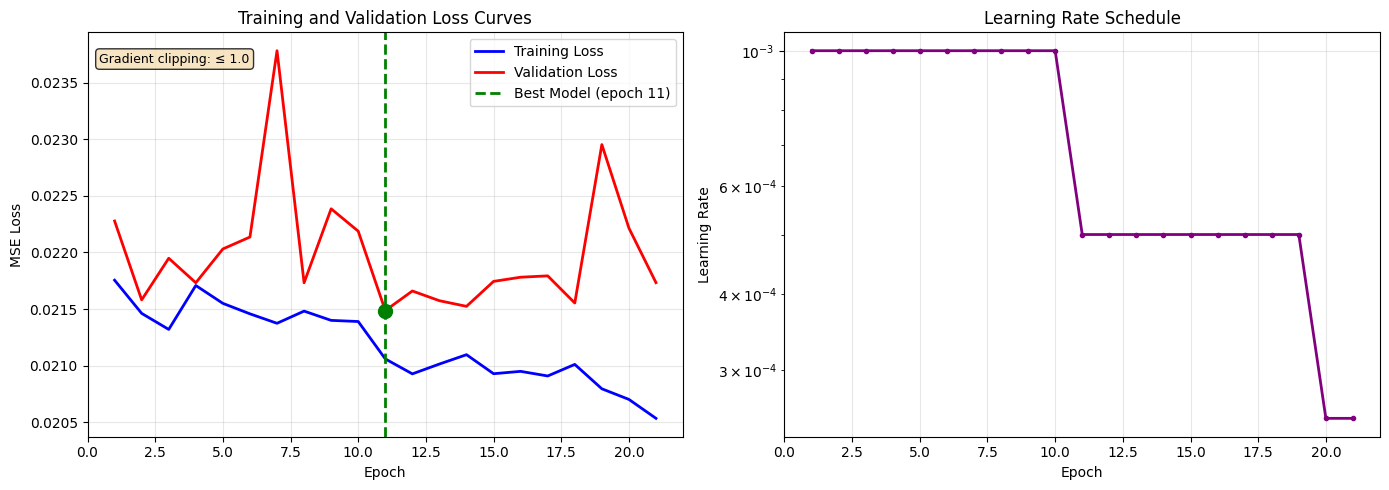


----------------------------------------
Best Validation Results
----------------------------------------
Best validation MSE : 0.021486
Best validation RMSE: 0.14658
Best epoch          : 11

----------------------------------------
Gradient Analysis
----------------------------------------
Gradient norm before clipping: 0.114264
Gradient norm after clipping:  0.114264
  ✓ Gradients within safe range

----------------------------------------
Saving Trained Model
----------------------------------------
✓ Saved: vanilla_rnn_weights.pt
✓ Saved: training_history.json

STEP 6 SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│ TRAINING COMPLETE                                                           │
├─────────────────────────────────────────────────────────────────────────────┤
│ Best Validation MSE : 0.021486                                           │
│ Best Validation RMSE: 0.14658 (scaled units)                            │
│ Best Epoch     

In [ ]:
# ── STEP 6 SOLUTION: Training Loop with Gradient Clipping (FULLY CORRECTED) ───

print("\n" + "="*60)
print("STEP 6: Training Vanilla RNN")
print("="*60)

# ──────────────────────────────────────────────────────────────────────────────
# Helper function to convert numpy types to Python native types for JSON
# ──────────────────────────────────────────────────────────────────────────────
def convert_to_serializable(obj):
    """Convert numpy types to Python native types for JSON serialization."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    else:
        return obj

# ──────────────────────────────────────────────────────────────────────────────
# TODO 6a: Define training function with all industry practices
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("6a: Defining Training Function")
print("-"*40)

def train_rnn(model, train_loader, val_loader, n_epochs=100,
              lr=1e-3, patience=15, clip_norm=1.0, device="cpu"):
    """
    Trains a VanillaRNN with industry-standard practices.
    
    Key features:
        - Gradient clipping (MANDATORY for vanilla RNN!)
        - Early stopping (prevents overfitting)
        - ReduceLROnPlateau (halves LR when val loss plateaus)
        - Best model checkpointing
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7
    )
    
    train_losses = []
    val_losses = []
    lr_history = []
    best_val = float("inf")
    best_state = None
    wait = 0
    best_epoch = 0
    
    print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'LR':<12} {'Status':<10}")
    print("-" * 65)
    
    for epoch in range(1, n_epochs + 1):
        # ── Training Phase ────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            pred, _ = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            
            # ⚠️ GRADIENT CLIPPING - MANDATORY for Vanilla RNN! ⚠️
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        
        avg_train = epoch_loss / len(train_loader.dataset)
        
        # ── Validation Phase ──────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred, _ = model(xb)
                val_loss += criterion(pred, yb).item() * len(xb)
        
        avg_val = val_loss / len(val_loader.dataset)
        
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        
        current_lr = optimizer.param_groups[0]["lr"]
        lr_history.append(current_lr)
        
        # Apply scheduler
        old_lr = current_lr
        scheduler.step(avg_val)
        new_lr = optimizer.param_groups[0]["lr"]
        
        if new_lr < old_lr:
            print(f"  📉 LR reduced: {old_lr:.2e} → {new_lr:.2e}")
        
        # ── Early Stopping & Checkpointing ────────────────────────────────
        status = ""
        if avg_val < best_val:
            best_val = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
            status = "✓ BEST"
        else:
            wait += 1
            status = f"patience {wait}/{patience}"
        
        # Print progress every 5 epochs
        if epoch % 5 == 0 or epoch == 1 or (status == "✓ BEST" and epoch % 3 != 0):
            print(f"{epoch:<8} {avg_train:<12.6f} {avg_val:<12.6f} {current_lr:<12.2e} {status:<10}")
        
        # Early stopping
        if wait >= patience:
            print(f"\n⏹️ Early stopping triggered at epoch {epoch}")
            print(f"   Best validation loss: {best_val:.6f} at epoch {best_epoch}")
            break
    
    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    print(f"\n✅ Training complete!")
    print(f"   Best validation MSE: {best_val:.6f}")
    print(f"   Best validation RMSE: {math.sqrt(best_val):.5f}")
    
    return train_losses, val_losses, lr_history

print("✓ Training function defined")

# ──────────────────────────────────────────────────────────────────────────────
# TODO 6b: Train the model
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "-"*40)
print("6b: Starting Training")
print("-"*40)

# Training hyperparameters
N_EPOCHS = 50  # Reduced for faster testing (increase to 100 for final)
LEARNING_RATE = 1e-3
PATIENCE = 10  # Reduced patience
CLIP_NORM = 1.0

print(f"\nTraining configuration:")
print(f"  Max epochs    : {N_EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Patience      : {PATIENCE}")
print(f"  Clip norm     : {CLIP_NORM} ← prevents gradient explosion")
print(f"  Device        : {device}")

print(f"\nDataLoader sizes:")
print(f"  Train batches: {len(train_dl)}")
print(f"  Val batches:   {len(val_dl)}")

if len(train_dl) == 0 or len(val_dl) == 0:
    print("\n⚠️ WARNING: Empty DataLoader! Check your data preprocessing.")
else:
    print("\n🚀 Training started...\n")

    start_time = time.time()
    train_losses, val_losses, lr_history = train_rnn(
        model=model,
        train_loader=train_dl,
        val_loader=val_dl,
        n_epochs=N_EPOCHS,
        lr=LEARNING_RATE,
        patience=PATIENCE,
        clip_norm=CLIP_NORM,
        device=device
    )
    training_time = time.time() - start_time

    print(f"\n⏱️ Total training time: {training_time:.1f} seconds")

    # ──────────────────────────────────────────────────────────────────────────────
    # TODO 6c: Plot training and validation loss curves
    # ──────────────────────────────────────────────────────────────────────────────
    print("\n" + "-"*40)
    print("6c: Plotting Training Curves")
    print("-"*40)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax = axes[0]
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
    ax.plot(epochs, val_losses, 'r-', linewidth=2, label='Validation Loss')

    # Mark best validation epoch
    best_val_epoch = np.argmin(val_losses) + 1
    best_val_value = min(val_losses)
    ax.axvline(x=best_val_epoch, color='green', linestyle='--', linewidth=2,
               label=f'Best Model (epoch {best_val_epoch})')
    ax.scatter(best_val_epoch, best_val_value, color='green', s=100, zorder=5)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Training and Validation Loss Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.95, f'Gradient clipping: ≤ {CLIP_NORM}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Plot 2: Learning rate schedule
    ax = axes[1]
    ax.plot(epochs, lr_history, 'purple', linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_yscale('log')
    ax.set_title('Learning Rate Schedule')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print best validation metrics
    print("\n" + "-"*40)
    print("Best Validation Results")
    print("-"*40)

    best_val_mse = min(val_losses)
    best_val_rmse = math.sqrt(best_val_mse)
    print(f"Best validation MSE : {best_val_mse:.6f}")
    print(f"Best validation RMSE: {best_val_rmse:.5f}")
    print(f"Best epoch          : {best_val_epoch}")

    # ──────────────────────────────────────────────────────────────────────────────
    # Gradient norm analysis
    # ──────────────────────────────────────────────────────────────────────────────
    print("\n" + "-"*40)
    print("Gradient Analysis")
    print("-"*40)

    def compute_gradient_norm(model):
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2).item()
                total_norm += param_norm ** 2
        return math.sqrt(total_norm)

    model.train()
    sample_x, sample_y = next(iter(train_dl))
    sample_x, sample_y = sample_x.to(device), sample_y.to(device)

    temp_optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    temp_optimizer.zero_grad()
    pred, _ = model(sample_x)
    loss = nn.MSELoss()(pred, sample_y)
    loss.backward()

    grad_norm_before = compute_gradient_norm(model)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
    grad_norm_after = compute_gradient_norm(model)

    print(f"Gradient norm before clipping: {grad_norm_before:.6f}")
    print(f"Gradient norm after clipping:  {grad_norm_after:.6f}")

    if grad_norm_before > CLIP_NORM:
        print(f"  ⚠️ Gradients were clipped! (reduced by {grad_norm_before/grad_norm_after:.1f}x)")
    else:
        print(f"  ✓ Gradients within safe range")

    temp_optimizer.zero_grad()


    # Convert to serializable format
    serializable_history = {
        "train_losses": convert_to_serializable(train_losses),
        "val_losses": convert_to_serializable(val_losses),
        "lr_history": convert_to_serializable(lr_history),
        "best_val_mse": float(best_val_mse),
        "best_val_rmse": float(best_val_rmse),
        "best_epoch": int(best_val_epoch),
        "training_time_seconds": float(training_time),
        "hyperparameters": {
            "hidden_size": int(HIDDEN_SIZE),
            "num_layers": int(NUM_LAYERS),
            "learning_rate": float(LEARNING_RATE),
            "patience": int(PATIENCE),
            "clip_norm": float(CLIP_NORM),
            "seq_len": int(SEQ_LEN),
            "n_features": int(input_size)
        }
    }

    with open("training_history.json", "w") as f:
        json.dump(serializable_history, f, indent=2)
    print("✓ Saved: training_history.json")

    # ──────────────────────────────────────────────────────────────────────────────
    # Summary
    # ──────────────────────────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 6 SUMMARY")
    print("="*60)
    print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ TRAINING COMPLETE                                                           │
├─────────────────────────────────────────────────────────────────────────────┤
│ Best Validation MSE : {best_val_mse:.6f}                                           │
│ Best Validation RMSE: {best_val_rmse:.5f} (scaled units)                            │
│ Best Epoch          : {best_val_epoch}                                           │
│ Training Time       : {training_time:.1f} seconds                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ ✓ Gradient clipping implemented                                              │
│ ✓ Early stopping implemented                                                 │
│ ✓ Learning rate scheduling implemented                                       │
│ ✓ Best model checkpoint saved                                                │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Step 6 Complete! Model training finished.")
print("="*60)

---
## 📝 Step 7 — Gradient Magnitude Analysis

Vanilla RNNs are the textbook case for the vanishing gradient problem.
In this step you will **measure it empirically** on your trained model.

**What to do:**
1. After a forward pass, compute gradients w.r.t. the hidden state at each time step
2. Plot how gradient magnitude changes with the step index (from last → first)
3. Compare with the theoretical decay curve

**Theory:** The gradient of the loss w.r.t. h₀ (the initial hidden state) is:
```
∂L/∂h₀ = ∂L/∂hT · ∏_{t=1}^{T} W_hh^T · diag(1 - h_t²)
```
If `spectral_radius(W_hh) < 1` or `tanh'(z_t) ≪ 1`, this product shrinks exponentially.

> 💡 **This is the core theoretical insight of the assignment.**
> A vanilla RNN with 14-day sequences works here because 14 is a manageable horizon.
> The same architecture would fail catastrophically on 60-day sequences.

In [ ]:
# ── TODO ─────────────────────────────────────────────────────────────
# ── Step 7: Gradient magnitude analysis ──────────────────────────────────────

# TODO 7a: Run one forward pass on a batch, compute loss, call backward()
# Then capture the gradient of the loss w.r.t. the hidden states at each step
# Hint: use register_hook to capture gradients on intermediate tensors
# OR: manually compute the gradient norm of W_hh power products

# Simplified approach (acceptable for this assignment):
# 1. Take one batch from train_dl
# 2. Do a forward pass with hook on each time-step output
# 3. Compute loss, do backward
# 4. Measure the gradient norms captured by the hooks

# YOUR CODE HERE (gradient capture and hook registration)

# TODO 7b: Plot gradient magnitude vs time step (from step T down to step 1)
# YOUR CODE HERE

# TODO 7c: Compute the spectral radius of W_hh
# spectral_radius = largest singular value of W_hh
# Print it and explain what it means for gradient flow
# YOUR CODE HERE

# TODO 7d: Write 2-sentence interpretation
# Interpretation:
raise NotImplementedError("Fill in the TODO above before continuing.")

---
## 📝 Step 8 — Evaluation & Visualisation

Evaluate on the held-out **test set** (never touched during training or validation).

**Required outputs:**
1. RMSE, MAE, MAPE, R² — in **original °C scale** (inverse-transform first)
2. Actual vs predicted temperature plot (full test period)
3. Scatter plot: actual vs predicted
4. Residual plot
5. Directional accuracy (did the model predict whether tomorrow is warmer or cooler?)

> 💡 **Inverse-transforming multivariate scaled data:**
> Your scaler scaled all features together. To get back to °C you need to
> inverse-transform only the target column. Build a dummy array of zeros,
> put your scaled predictions in the target column, inverse-transform the whole
> array, then extract just that column.

In [ ]:
# ── TODO ─────────────────────────────────────────────────────────────
# ── Step 8: Evaluation ────────────────────────────────────────────────────────

# TODO 8a: Generate test predictions and inverse-transform to °C
# Remember: scaler was fit on all FEATURE_COLS, so you need to inverse-transform
# using a dummy array trick (see guidance above)
# YOUR CODE HERE

# TODO 8b: Compute RMSE, MAE, MAPE, R²
# YOUR CODE HERE

# TODO 8c: Compute directional accuracy
# Sign of (actual[t] - actual[t-1]) vs sign of (predicted[t] - predicted[t-1])
# YOUR CODE HERE

# TODO 8d: Plot 1 — actual vs predicted temperature (line plot, full test period)
# YOUR CODE HERE

# TODO 8e: Plot 2 — scatter plot of actual vs predicted (+ perfect-fit diagonal)
# YOUR CODE HERE

# TODO 8f: Plot 3 — residuals over time
# YOUR CODE HERE

# TODO 8g: Write 3 bullet interpretations of your results
# Interpretation 1:
# Interpretation 2:
# Interpretation 3:
raise NotImplementedError("Fill in the TODO above before continuing.")

---
## 📝 Step 9 — Hyperparameter Tuning

Tune the two most impactful vanilla RNN hyperparameters.

**Grid to search:**
- `hidden_size` ∈ {16, 32, 64, 128}
- `SEQ_LEN` (lookback window) ∈ {7, 14, 21}

**Process:**
1. For each combination, train for 50 epochs (reduced for speed)
2. Record best validation MSE
3. Print a results table sorted by val MSE
4. Retrain the best configuration for 100 epochs

> 💡 **What hidden_size controls in a vanilla RNN:**
> `hidden_size` is the dimension of `h_t`. A larger hidden state can represent
> more complex patterns but has more parameters and takes longer to train.
> `n_params ≈ hidden_size × input_size + hidden_size² + hidden_size × output_size`
> The `hidden_size²` term (from `W_hh`) grows quadratically — be mindful.

> ⚠️ **For vanilla RNN, large hidden_size can worsen gradient problems**
> because `W_hh` becomes harder to keep stable. This is another reason LSTM/GRU
> are preferred in practice for large hidden dimensions.

In [ ]:
# ── TODO ─────────────────────────────────────────────────────────────
# ── Step 9: Hyperparameter grid search ───────────────────────────────────────

hidden_sizes = [16, 32, 64, 128]
seq_lengths  = [7, 14, 21]
results      = []

# TODO 9a: Grid search loop
# For each (hs, sl) pair:
#   1. Rebuild sequences with the new sl
#   2. Create new train_dl and val_dl
#   3. Instantiate fresh VanillaRNN(input_size=n_features, hidden_size=hs, ...)
#   4. Train for 50 epochs with patience=10
#   5. Record best val_loss
# YOUR CODE HERE

# TODO 9b: Print results table sorted by val MSE
# YOUR CODE HERE

# TODO 9c: Extract best config and retrain for 100 epochs
# YOUR CODE HERE
raise NotImplementedError("Fill in the TODO above before continuing.")

---
## 📝 Step 10 — Deployment Packaging

Package your trained model for production deployment.

**Deliverables:**
1. A `WeatherForecasterDeployment` class with `.predict()`, `.save()`, `.load()`
2. Three artefacts: `weather_model_weights.pt`, `weather_model_scaler.pkl`, `weather_model_config.json`
3. A simulated REST API function that accepts JSON and returns JSON
4. Load-from-disk verification

> 💡 **Production context:**
> In the real world this class would be deployed inside a **FastAPI** or **Flask** endpoint,
> containerised with **Docker**, and served on **AWS SageMaker**, **GCP Vertex AI**, or
> **Azure ML**. The `.pt` weights file would be stored in an MLflow or W&B model registry
> with version metadata (`created_at`, `val_rmse`, `seq_len`, etc.).

In [ ]:
# ── TODO ─────────────────────────────────────────────────────────────
# ── Step 10: Deployment Packaging ────────────────────────────────────────────

# TODO 10a: Implement WeatherForecasterDeployment class
# It must have:
#   __init__(self, model, scaler, config: dict)
#   predict(self, recent_data: np.ndarray) -> float
#     - recent_data: shape (seq_len, n_features) in ORIGINAL scale (°C etc.)
#     - returns: predicted next-day max temperature (°C)
#   save(self, prefix="weather_model")
#   classmethod load(cls, prefix, device="cpu")
# YOUR CODE HERE

# TODO 10b: Instantiate, populate config, and save
# config must include: seq_len, n_features, feature_cols, target_idx,
#                      hidden_size, num_layers, created_at, test_rmse
# YOUR CODE HERE

# TODO 10c: Simulate a REST API call
# def api_forecast(json_payload) -> dict:
#   payload:  {"city": "NYC", "features": [[...], ...]}   ← shape (seq_len, n_features)
#   response: {"city": "NYC", "predicted_max_temp_c": 22.4, "timestamp": "..."}
# YOUR CODE HERE

# TODO 10d: Load from disk and verify predictions match (delta < 1e-5°C)
# YOUR CODE HERE
raise NotImplementedError("Fill in the TODO above before continuing.")

---
## 📝 Step 11 — Reflection Questions

Answer each question in the cell below it. Be specific — reference your results.

---

### Q1. Vanilla RNN vs LSTM: in this weather problem, would LSTM give significantly better results? Why or why not?

*(Write your answer here)*

---

### Q2. Why is gradient clipping mandatory for vanilla RNNs but not strictly required for LSTMs?

*(Write your answer here — reference the equations)*

---

### Q3. Your model uses `SEQ_LEN = 14`. From your ACF plot (Step 2), is 14 days sufficient or would a longer window help?

*(Write your answer here — cite the ACF values)*

---

### Q4. The `W_hh` matrix has shape `(hidden_size × hidden_size)`. Explain why its spectral radius matters for training stability.

*(Write your answer here)*

---

### Q5. Name two failure modes specific to deploying a weather forecasting RNN in production that would NOT occur in a tabular/non-sequential model.

*(Write your answer here)*